In [31]:
import numpy as np
from datetime import datetime 

from synoptic import TimeSeries
import easysnowdata as esd 

from typing import List, Set

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import xarray as xr
import rioxarray as rio
import seaborn as sns
sns.set_theme()
import pandas as pd
pd.set_option('display.precision', 2)

from pathlib import Path

import math
import gc
import os 

# Looking at short baseline flights over my study areas

I'm expecting three flights from RMNP and six flights from SLC. 

RMNP were all 7 day baselines while SLC had between 6 and 8 day baselines. 

In [3]:
data_dir = '/bsuhome/julialober/scratch/coherence_data/'
slc = xr.open_zarr(data_dir + 'stacks/slc_box_swe')

t1_str = slc["pair"].str[:6]
t2_str = slc["pair"].str[7:]
# print(t1_str)
t1_formatted = "20" + t1_str.str[:2] + "-" + t1_str.str[2:4] + "-" + t1_str.str[4:]
t2_formatted = "20" + t2_str.str[:2] + "-" + t2_str.str[2:4] + "-" + t2_str.str[4:]
t1_dt = t1_formatted.astype("datetime64[s]")
t2_dt = t2_formatted.astype("datetime64[s]")
# print(t1_dt[0], t2_dt[0])
days_elapsed = (t2_dt - t1_dt) / np.timedelta64(1, "D")
# print(days_elapsed[0])
slc["temp_baseline"] = days_elapsed
slc = slc.sel(pair=(days_elapsed <= 8))

rmnp = xr.open_zarr(data_dir + 'stacks/rmnp_box_swe')

t1_str = rmnp["pair"].str[:6]
t2_str = rmnp["pair"].str[7:]
# print(t1_str)
t1_formatted = "20" + t1_str.str[:2] + "-" + t1_str.str[2:4] + "-" + t1_str.str[4:]
t2_formatted = "20" + t2_str.str[:2] + "-" + t2_str.str[2:4] + "-" + t2_str.str[4:]
t1_dt = t1_formatted.astype("datetime64[s]")
t2_dt = t2_formatted.astype("datetime64[s]")
# print(t1_dt[0], t2_dt[0])
days_elapsed = (t2_dt - t1_dt) / np.timedelta64(1, "D")
# print(days_elapsed[0])
rmnp["temp_baseline"] = days_elapsed
rmnp = rmnp.sel(pair=(days_elapsed <= 8))

print(f"RMNP number of pairs < 8 days: {len(rmnp['pair'])}")
for p in rmnp['pair'].values: 
    print(f"{p}: {rmnp.sel(pair=p)['temp_baseline'].values}")
print(f"SLC number of pairs < 8 days: {len(slc['pair'])}")
for p in slc['pair'].values: 
    print(f"{p}: {slc.sel(pair=p)['temp_baseline'].values}")

RMNP number of pairs < 8 days: 3
200212_200219: 7.0
210127_210203: 7.0
210303_210310: 7.0
SLC number of pairs < 8 days: 6
200213_200221: 8.0
210203_210210: 7.0
210223_210303: 8.0
210303_210310: 7.0
210310_210316: 6.0
210316_210322: 6.0


## Filter for physical parameters and cross-pol coherence 

In [4]:
inc_cutoff = 80
canopy_cutoff = 30
elev_quant = 60

In [5]:
def filter_data(data) : 
    single_year_pairs = [
        p for p in data.coords['pair'].values 
        if p[:2] == p[7:9]
    ]

    print(f'Filtering for {len(single_year_pairs)} single-year pairs.')
    data = data.sel(pair=single_year_pairs)

    print(f'Trimming to DEM.')
    data = data.where(data['elevation'].notnull())

    print(f'Filtering inc angle > {inc_cutoff}, canopy cover > {canopy_cutoff}, elev top {elev_quant}%.')
    condition = (data['incidence_angle'] < inc_cutoff) & \
                (data['canopy_2019'] < canopy_cutoff) & \
                (data['elevation'] > data['elevation'].quantile((100-elev_quant)/100))

    data = data.where(condition)

    return data

In [6]:
rmnp_good = filter_data(rmnp)
slc_good = filter_data(slc)

Filtering for 3 single-year pairs.
Trimming to DEM.
Filtering inc angle > 80, canopy cover > 30, elev top 60%.
Filtering for 6 single-year pairs.
Trimming to DEM.
Filtering inc angle > 80, canopy cover > 30, elev top 60%.


In [7]:
xpol_cutoff = 0.9
to_filter = rmnp_good 

In [8]:
def filter_and_plot_pairs(
    dataset: xr.Dataset, 
    coh_dir: Path, 
    cutoff: float
) -> xr.Dataset:
    """
    Pre-loads cross-pol coherences, applies a cutoff mask to reference and secondary
    flights, plots a 3-panel figure per pair, and returns the filtered dataset.
    
    Args:
        dataset: The target InSAR xarray.Dataset (e.g., rmnp_good).
        coh_dir: Pathlib object pointing to the directory of cross-pol tif files.
        cutoff: The cross-pol coherence threshold to apply to the mask.
        
    Returns:
        A fully masked xarray.Dataset concatenated back along the 'pair' dimension.
    """
    
    # 1. Extract unique dates to avoid redundant loading
    all_pairs: List[str] = dataset['pair'].values.tolist()
    unique_dates: Set[str] = set()
    for pair_name in all_pairs:
        # Utilizing character slicing as determined in our previous session
        unique_dates.add(pair_name[:6])  
        unique_dates.add(pair_name[7:13]) 

    # print(unique_dates)
        
    # 2. Pre-load all unique cross-pol rasters into a single datacube
    xpol_list: List[xr.DataArray] = []
    valid_dates: List[str] = []
    
    
    for date_str in sorted(list(unique_dates)):
        file_path_list = list(coh_dir.glob(f"*{date_str}*_crosspol_coh.tif"))
        # print(file_path_list)
        
        try:
            # Enforce API safety / File loader robustness
            if not file_path_list:
                raise FileNotFoundError(f"Missing cross-pol raster for date: {date_str}")
            
            # Squeeze band, assign the date as a coordinate, and append
            da = rio.open_rasterio(file_path_list[0]).squeeze('band', drop=True)
            da = da.assign_coords(date=date_str)
            xpol_list.append(da)
            valid_dates.append(date_str)
            
        except Exception as e:
            print(f"[ERROR] Failed to load cross-pol data for {date_str}: {e}")
            continue
            
    # Combine into a single cube and reproject ONCE to match target grid
    print(f"Reprojecting cross-pol datacube for {len(valid_dates)} unique flights...")
    xpol_cube = xr.concat(xpol_list, dim='date')
    xpol_cube = xpol_cube.rio.reproject_match(dataset)
    
    # 3. Iterate through pairs to mask and plot
    filtered_subsets: List[xr.Dataset] = []
    
    for pair_name in all_pairs:
        ref_date = pair_name[:6]
        sec_date = pair_name[7:13]
        
        # Fast in-memory selection
        xpol_ref = xpol_cube.sel(date=ref_date)
        xpol_sec = xpol_cube.sel(date=sec_date)
        
        # Calculate mask: both reference AND secondary flights must exceed cutoff
        crosspol_mask = (xpol_ref >= cutoff) & (xpol_sec >= cutoff)
        
        # Isolate the specific pair while retaining the 'pair' dimension
        target_pair = dataset.sel(pair=[pair_name])
        
        # Safely handle NoData / apply mask
        filtered_pair = target_pair.where(crosspol_mask)
        filtered_subsets.append(filtered_pair)
        
        # --- Plotting Subroutine ---
        fig, axes = plt.subplots(1, 4, figsize=(22, 5))
        
        target_pair['coherence'].plot(ax=axes[0], cmap='viridis', vmin=0, vmax=1, cbar_kwargs={'shrink': 0.7})
        axes[0].set_title(f"Reference Cross-Pol Coherence\n({ref_date})")
        axes[0].set_aspect('equal')

        # Ensure we are handling spatial constants / NaN display natively via xarray plotting
        xpol_ref.plot(ax=axes[1], cmap='viridis', vmin=0, vmax=1, cbar_kwargs={'shrink': 0.7})
        axes[1].set_title(f"Reference Cross-Pol Coherence\n({ref_date})")
        axes[1].set_aspect('equal')
        
        xpol_sec.plot(ax=axes[2], cmap='viridis', vmin=0, vmax=1, cbar_kwargs={'shrink': 0.7})
        axes[2].set_title(f"Secondary Cross-Pol Coherence\n({sec_date})")
        axes[2].set_aspect('equal')
        
        # Squeeze out the 'pair' dim just for the 2D plot, plotting actual InSAR coherence
        filtered_pair['coherence'].squeeze().plot(ax=axes[3], cmap='inferno', vmin=0, vmax=1, cbar_kwargs={'shrink': 0.7})
        axes[3].set_title(f"Masked Interferometric Coherence\n({pair_name})")
        axes[3].set_aspect('equal')
        
        plt.tight_layout()
        plt.show() # In an HPC batch script, change this to plt.savefig()
        
    # 4. Re-assemble the fully masked multidimensional dataset
    return xr.concat(filtered_subsets, dim='pair')

Reprojecting cross-pol datacube for 6 unique flights...


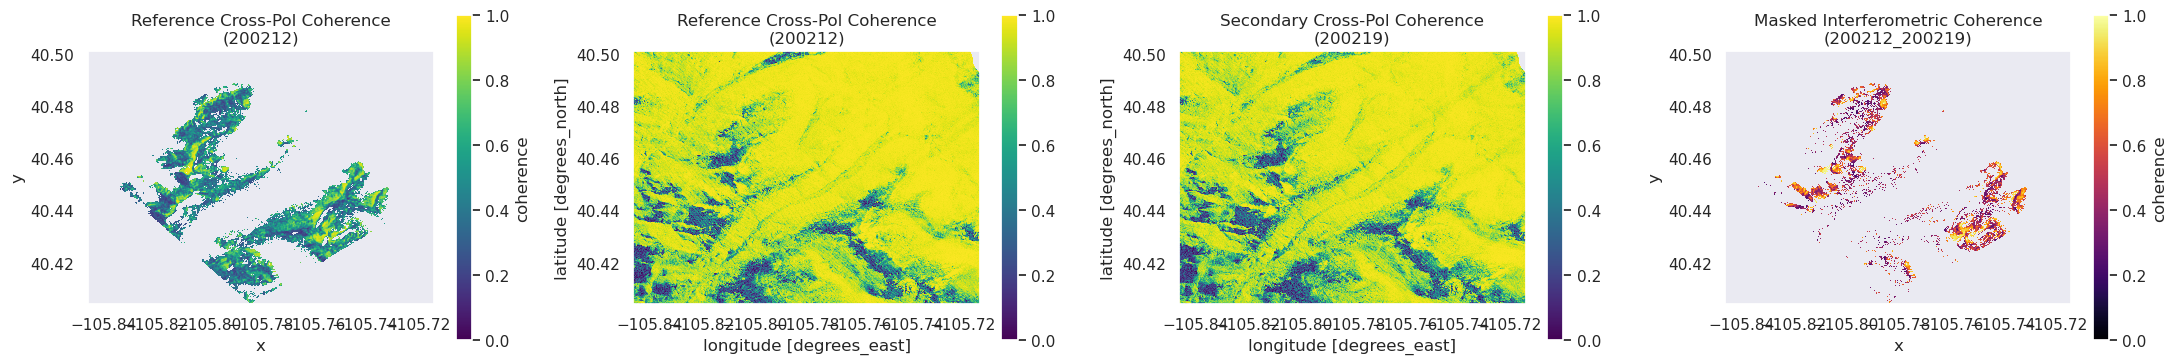

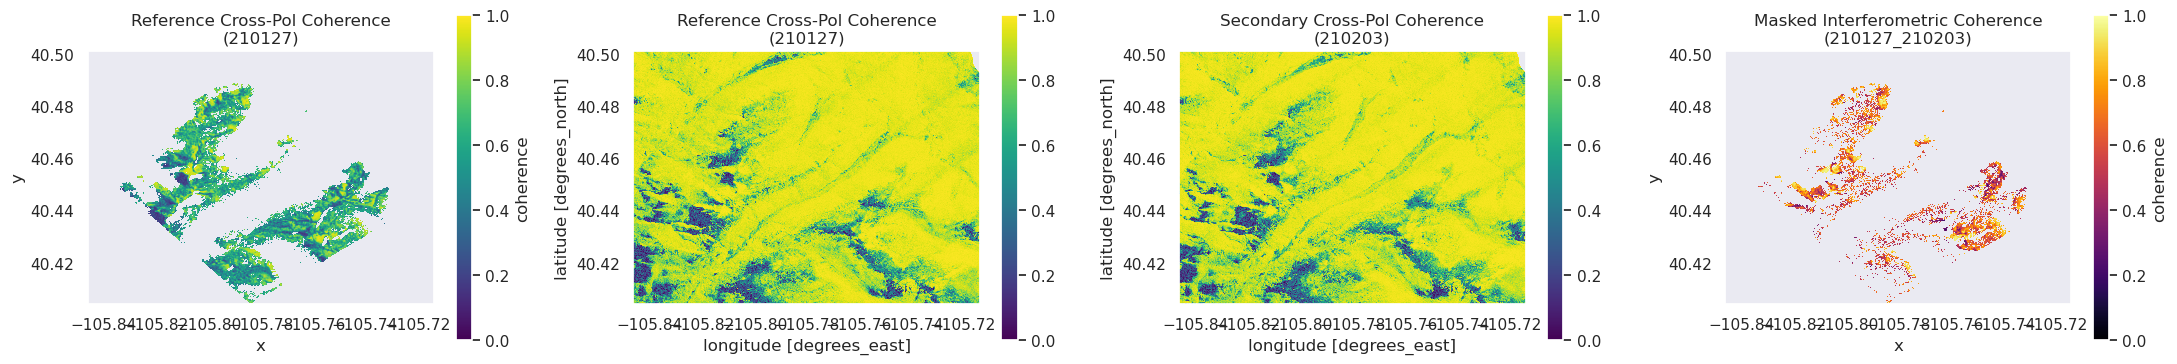

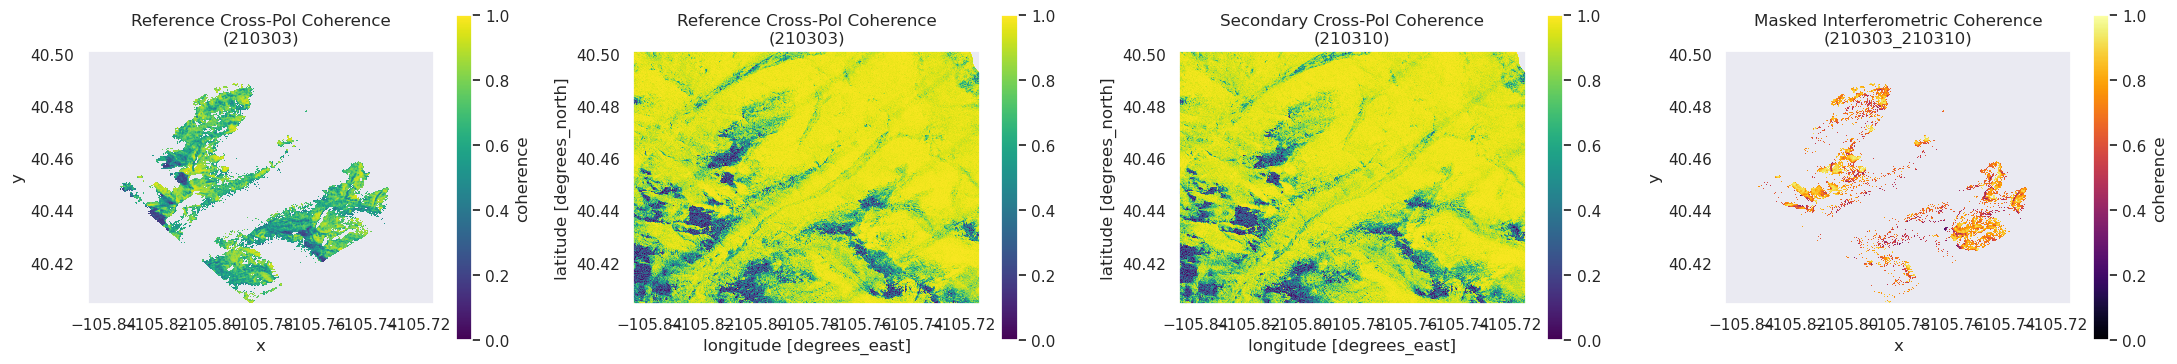

/tmp/ipykernel_2618/3653827858.py:104: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  return xr.concat(filtered_subsets, dim='pair')


In [9]:
coh_dir: Path = Path(f"{data_dir}/uavsar_cohs/rockmt/32109/")
rmnp_filtered = filter_and_plot_pairs(rmnp_good, coh_dir, xpol_cutoff)

Reprojecting cross-pol datacube for 9 unique flights...


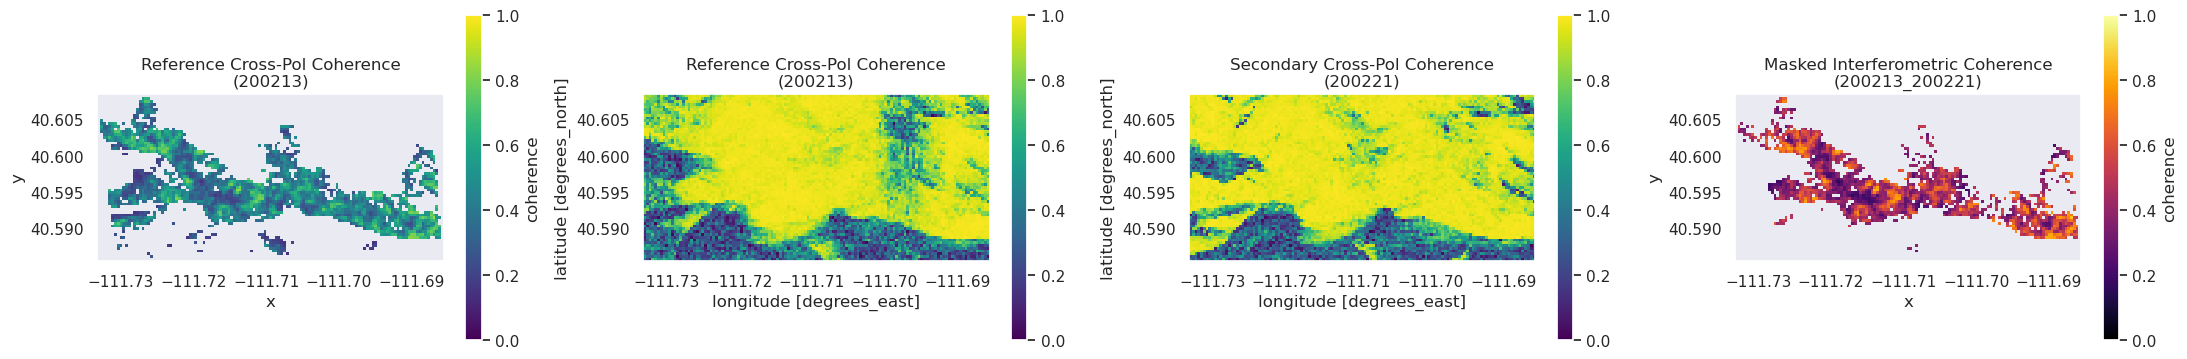

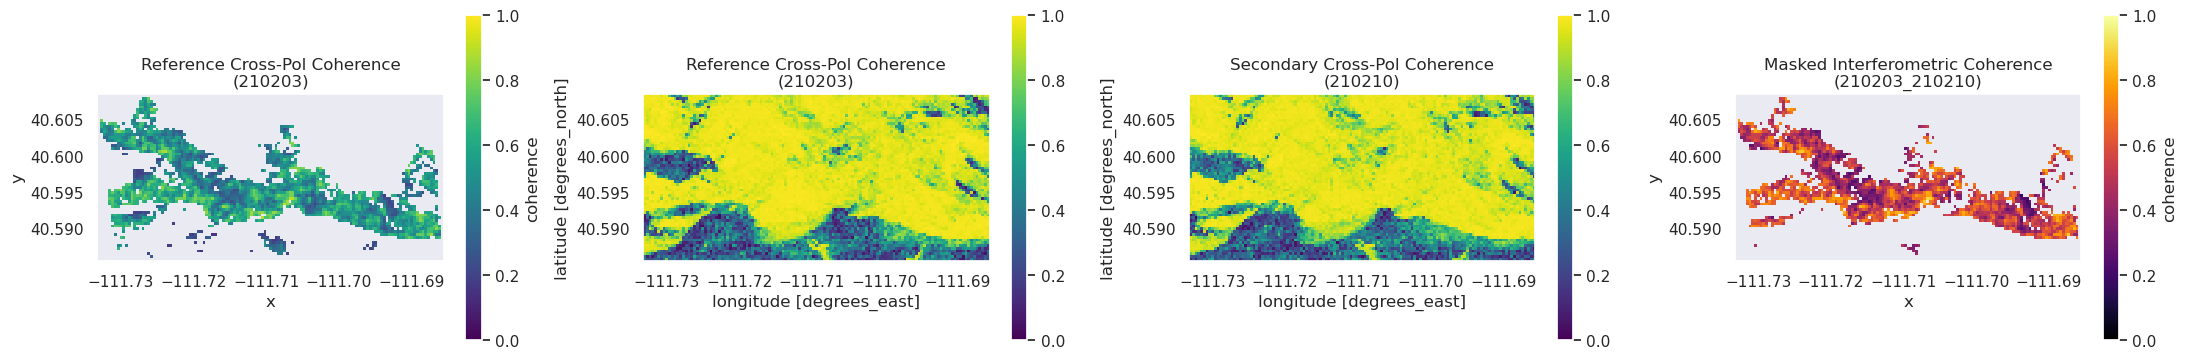

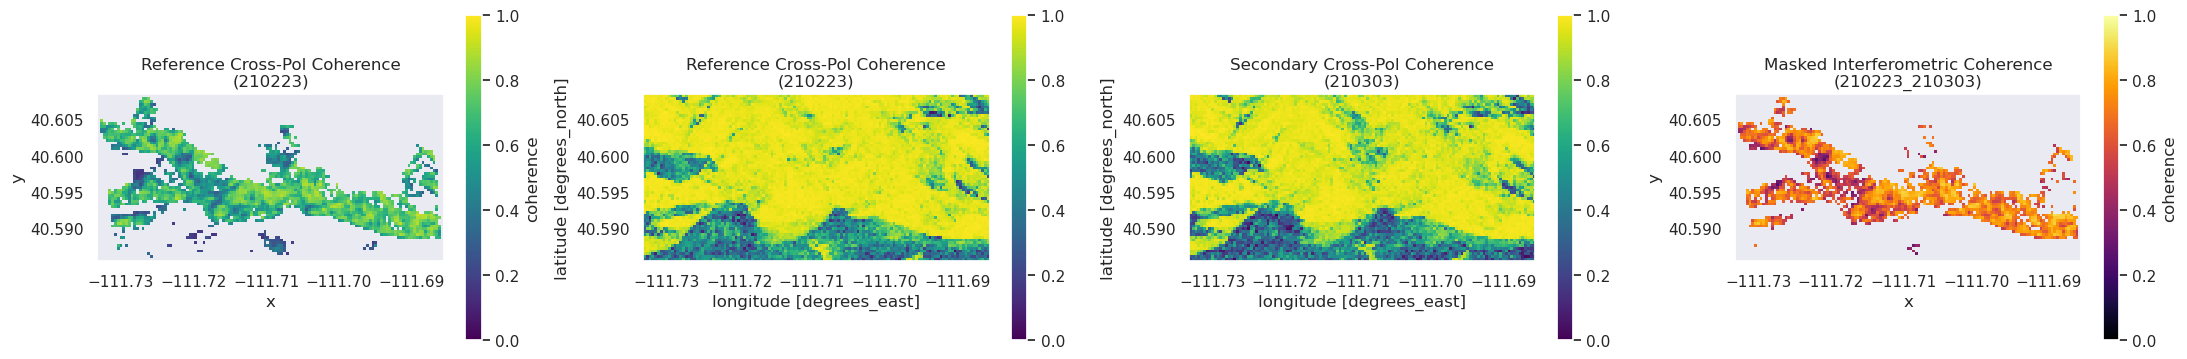

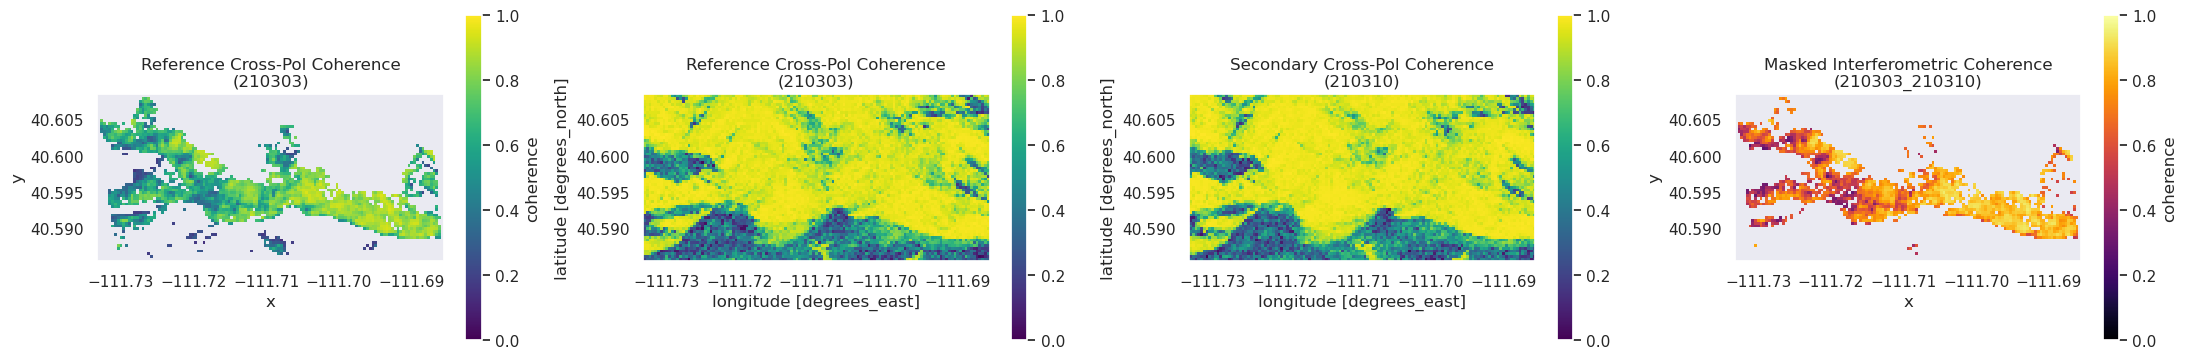

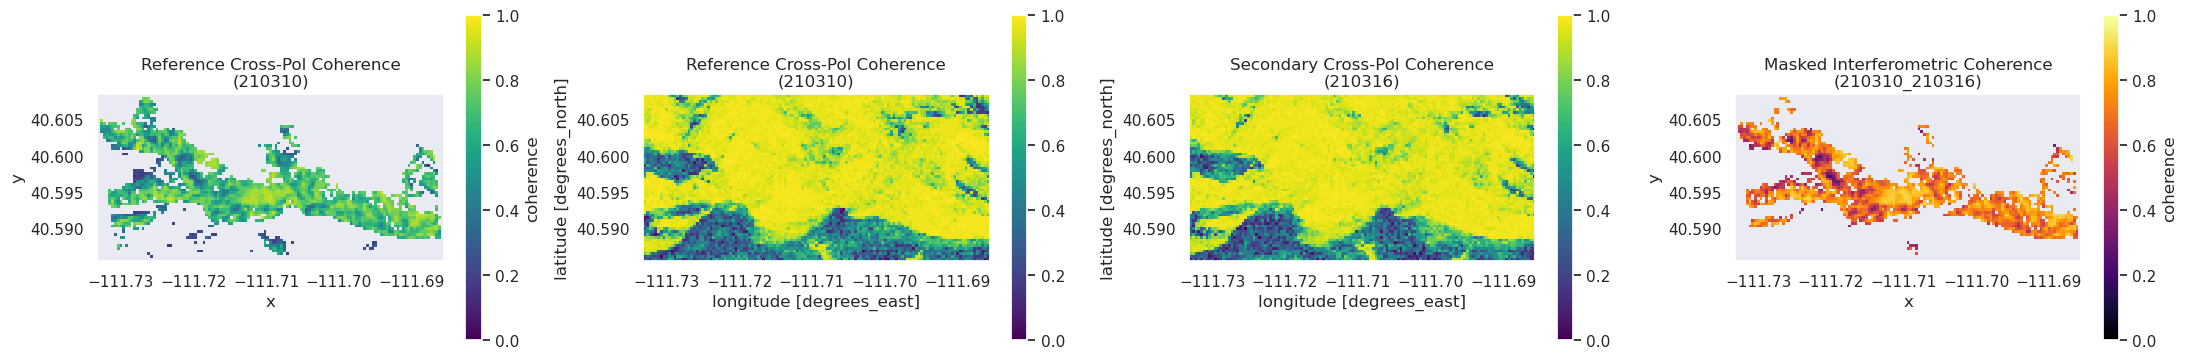

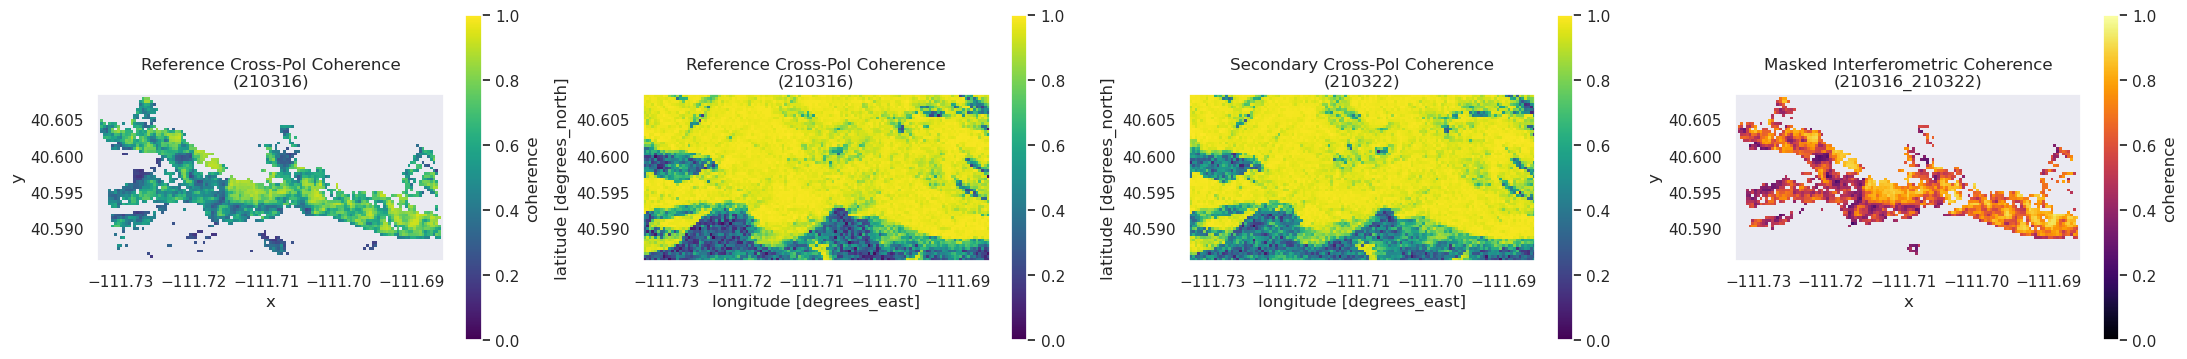

/tmp/ipykernel_2618/3653827858.py:104: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  return xr.concat(filtered_subsets, dim='pair')


In [10]:
coh_dir: Path = Path(f"{data_dir}/uavsar_cohs/stlake/27129/")
slc_filtered = filter_and_plot_pairs(slc_good, coh_dir, xpol_cutoff)

## Download SNOTEL (snow) and MesoWest (wind) data

I have 3 nearby SNOTEL sites for each location. 

Utah: Snowbird, Brighton, and Thaynes 
Colorado: Cameron Pass, Willow Park, Lake Irene 

In [11]:
snotels = esd.automatic_weather_stations.StationCollection()
print(snotels.all_stations[snotels.all_stations['state'] == 'Utah'])


                          name network  elevation_m  latitude  longitude  \
code                                                                       
907_UT_SNTL        Agua Canyon  SNOTEL      2712.72     37.52    -112.27   
992_UT_SNTL      Bear River RS  SNOTEL      2675.23     40.89    -110.83   
329_UT_SNTL        Beaver Dams  SNOTEL      2435.35     39.14    -111.56   
330_UT_SNTL      Beaver Divide  SNOTEL      2523.74     40.61    -111.10   
332_UT_SNTL    Ben Lomond Peak  SNOTEL      2343.61     41.38    -111.94   
...                        ...     ...          ...       ...        ...   
853_UT_SNTL       Webster Flat  SNOTEL      2805.07     37.58    -112.90   
864_UT_SNTL     White River #1  SNOTEL      2633.78     39.96    -110.99   
865_UT_SNTL         Widtsoe #3  SNOTEL      2938.27     37.84    -111.88   
1228_UT_SNTL     Wrigley Creek  SNOTEL      2842.87     39.13    -111.36   
1197_UT_SNTL  Yankee Reservoir  SNOTEL      2649.32     37.75    -112.77   

           

In [12]:

snotel_mapping = {
    'Cameron': {'triplet': '551_CO_SNTL', 'name': 'Joe Wright'},
    'Willow': {'triplet': '870_CO_SNTL', 'name': 'Willow Park'},
    'Irene': {'triplet': '565_CO_SNTL', 'name': 'Lake Irene'},
    'Brighton' : {'triplet': '366_UT_SNTL', 'name': 'Brighton'},
    'Snowbird': {'triplet': '766_UT_SNTL', 'name': 'Snowbird'},
    'Thaynes': {'triplet': '814_UT_SNTL', 'name': 'Thaynes'},
}

# Define our target evaluation windows across both winter seasons
date_ranges = [
    {'start': '2019-12-01', 'end': '2020-04-01', 'label': 'Winter_2020'},
    {'start': '2020-12-01', 'end': '2021-04-01', 'label': 'Winter_2021'},
]

# Create a clean dictionary container to store your final timeseries arrays
snotel_timeseries_data = {}
snotel_metadata = {}

for site_id, station in snotel_mapping.items():
    snotel_metadata[site_id] = snotels.all_stations.loc[station['triplet']]

    snotel_timeseries_data[site_id] = {}
    print(f"Fetching full historical table for SNOTEL: {station['name']} ({station['triplet']})...")
    
    # Fetch the entire historical table using your snotels instance method
    sntl = esd.automatic_weather_stations.StationCollection()
    sntl.get_data(station['triplet'])  # This should return a DataFrame with a datetime index
    df_full = sntl.data
    
    # Ensure the index is explicitly formatted as a DatetimeIndex so slicing works perfectly
    df_full.index = pd.to_datetime(df_full.index)
    
    for period in date_ranges:
        # Slice the full dataframe to the specific window bounds
        df_clipped = df_full.loc[period['start']:period['end']]
        
        if not df_clipped.empty:
            snotel_timeseries_data[site_id][period['label']] = df_clipped
            print(f"Successfully clipped {period['label']} data array ({len(df_clipped)} records).")
        else:
            print(f"No records found for {station['name']} after clipping to {period['label']}.")


Fetching full historical table for SNOTEL: Joe Wright (551_CO_SNTL)...
Successfully clipped Winter_2020 data array (123 records).
Successfully clipped Winter_2021 data array (122 records).
Fetching full historical table for SNOTEL: Willow Park (870_CO_SNTL)...
Successfully clipped Winter_2020 data array (123 records).
Successfully clipped Winter_2021 data array (122 records).
Fetching full historical table for SNOTEL: Lake Irene (565_CO_SNTL)...
Successfully clipped Winter_2020 data array (123 records).
Successfully clipped Winter_2021 data array (122 records).
Fetching full historical table for SNOTEL: Brighton (366_UT_SNTL)...
Successfully clipped Winter_2020 data array (123 records).
Successfully clipped Winter_2021 data array (122 records).
Fetching full historical table for SNOTEL: Snowbird (766_UT_SNTL)...
Successfully clipped Winter_2020 data array (123 records).
Successfully clipped Winter_2021 data array (122 records).
Fetching full historical table for SNOTEL: Thaynes (814_UT

In [13]:

print(snotel_metadata)

{'Cameron': name                                                Joe Wright
network                                                 SNOTEL
elevation_m                                            3084.58
latitude                                                 40.53
longitude                                              -105.89
state                                                 Colorado
HUC                                               101900070204
mgrs                                                     13TDE
mountainRange                         Southern Rocky Mountains
beginDate                                  1978-10-01 00:00:00
endDate                                    2026-06-24 00:00:00
csvData                                                   True
geometry         POINT (-105.88700103759766 40.53215026855469)
Name: 551_CO_SNTL, dtype: object, 'Willow': name                                               Willow Park
network                                                 SNOTEL

In [14]:
def read_synoptic_csv(file_path):
    metadata = {}

    # 1. Read the top comment lines to extract metadata
    with open(file_path, "r") as file:
        for line in file:
            # Stop searching if we hit a line that doesn't start with a comment
            if not line.startswith("#"):
                break

            # Check for specific metadata tags in the comment line
            if "STATION:" in line:
                metadata["station_code"] = line.split("STATION:")[-1].strip()
            elif "STATION NAME:" in line:
                metadata["station_name"] = (
                    line.split("STATION NAME:")[-1].strip()
                )
            elif "LATITUDE:" in line:
                metadata["latitude"] = float(line.split("LATITUDE:")[-1])
            elif "LONGITUDE:" in line:
                metadata["longitude"] = float(line.split("LONGITUDE:")[-1])
            elif "ELEVATION" in line:
                # Extracts elevation and converts feet to meters if desired
                elevation_ft = float(line.split(":")[-1])
                metadata["elevation_ft"] = elevation_ft
                metadata["elevation_m"] = round(elevation_ft * 0.3048, 2)
            elif "STATE:" in line:
                metadata["state"] = line.split("STATE:")[-1].strip()
    df_weather = pd.read_csv(file_path, header=[10, 11])

    return metadata, df_weather

# iff_meta, iff_stn = read_synoptic_csv(data_dir + 'stations/mesowest/IFF_cardiff_peak_20260424.csv')
# rey_meta, rey_stn = read_synoptic_csv(data_dir + 'stations/mesowest/REY_reynolds_peak_20260424.csv')
# hdp_meta, hdp_stn = read_synoptic_csv(data_dir + 'stations/mesowest/HDP_hidden_peak_20260424.csv')
# print(iff_meta)

In [15]:
# List of your downloaded CSV files
csv_files = ["IFF_cardiff_peak_20260424.csv", 
             "REY_reynolds_peak_20260424.csv", 
             "HDP_hidden_peak_20260424.csv"]

meso_timeseries_data = {}
meso_metadata = {}

date_ranges = [
    {"start": "2019-12-01", "end": "2020-04-01", "label": "Winter_2020"},
    {"start": "2020-12-01", "end": "2021-04-01", "label": "Winter_2021"},
]

for file_path in csv_files:
    # Safely parse the metadata headers and the dataframe separately
    meta, df_raw = read_synoptic_csv(data_dir + 'stations/mesowest/' + file_path)

    # Store metadata globally using the Station ID as the key (e.g., 'HDP')
    station_id = meta["station_code"]
    meso_metadata[station_id] = meta

    # --- Standard Cleaning Steps from before ---
    df_raw.columns = df_raw.columns.get_level_values(0)
    df_raw["Date_Time"] = pd.to_datetime(
        df_raw["Date_Time"], utc=True
    ).dt.tz_localize(None)
    df_raw = df_raw.dropna(axis=1, how="all")

    # Set index for time slicing
    station_df = df_raw.set_index("Date_Time").sort_index()
    if "Station_ID" in station_df.columns:
        station_df = station_df.drop(columns=["Station_ID"])

    # Slice seasons
    station_seasons = {}
    for period in date_ranges:
        start_date = pd.to_datetime(period["start"])
        end_date = pd.to_datetime(period["end"])

        season_df = station_df.loc[start_date:end_date].copy()

        if not season_df.empty:
            season_df = season_df.dropna(axis=1, how="all")

            # Attach the parsed text metadata straight onto the dataframe attribute
            season_df.attrs["metadata"] = meta
            station_seasons[period["label"]] = season_df

    meso_timeseries_data[station_id] = station_seasons

In [16]:
print(meso_metadata)

{'IFF': {'station_code': 'IFF', 'station_name': 'CARDIFF PEAK', 'latitude': 40.595, 'longitude': -111.6519, 'elevation_ft': 10059.0, 'elevation_m': 3065.98, 'state': 'UT'}, 'REY': {'station_code': 'REY', 'station_name': 'Reynolds Peak', 'latitude': 40.662117, 'longitude': -111.646764, 'elevation_ft': 9400.0, 'elevation_m': 2865.12, 'state': 'UT'}, 'HDP': {'station_code': 'HDP', 'station_name': 'Hidden Peak', 'latitude': 40.56106, 'longitude': -111.64522, 'elevation_ft': 11000.0, 'elevation_m': 3352.8, 'state': 'UT'}}


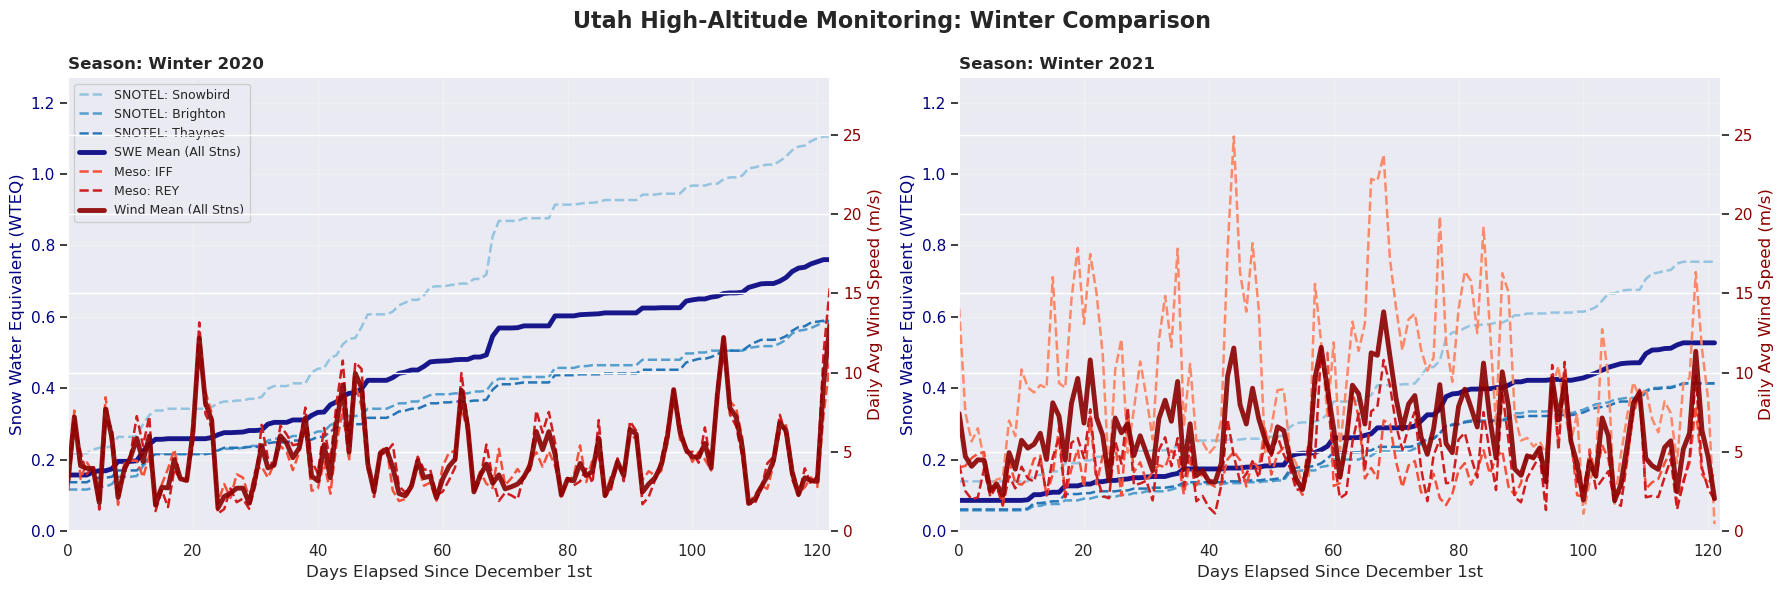

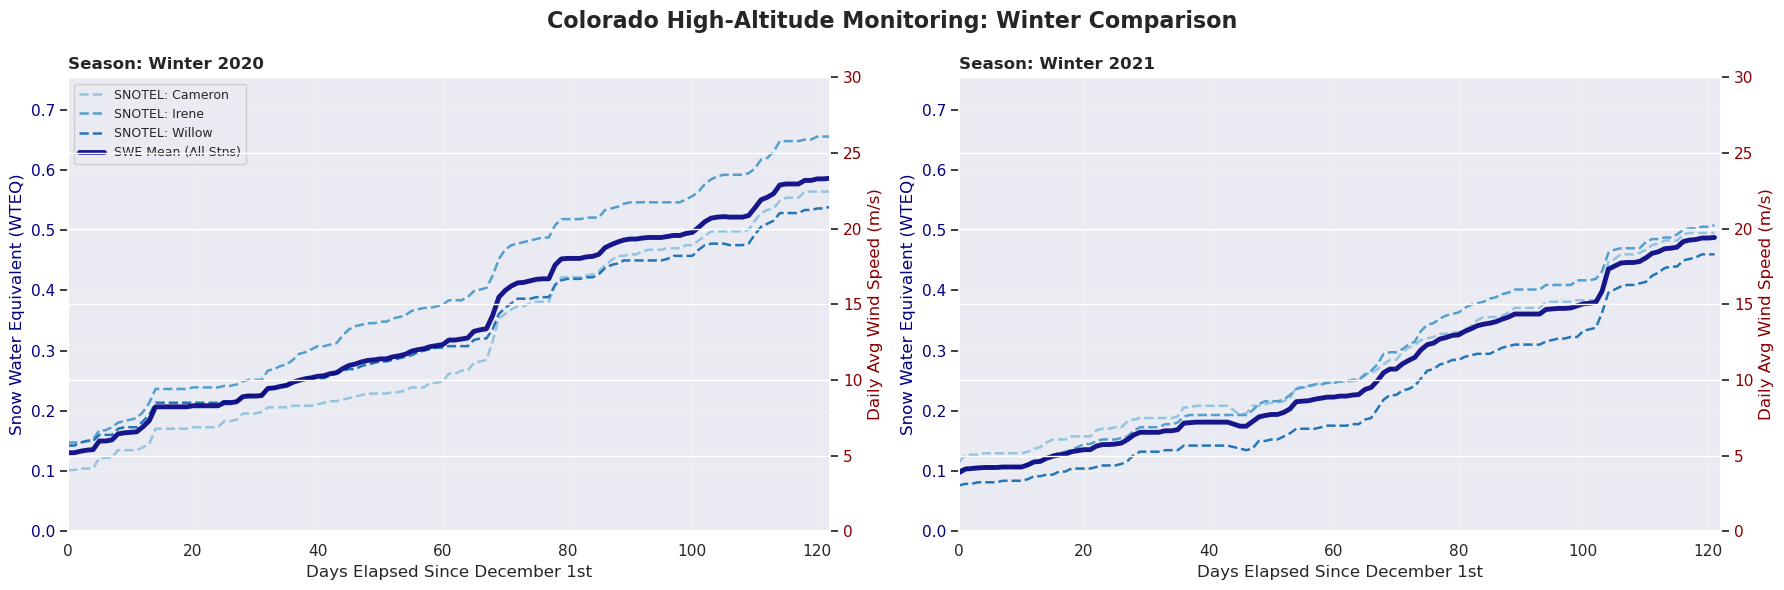

In [37]:

utah_snotel_stations = ["Snowbird", "Brighton", "Thaynes"]
colorado_snotel_stations = ["Cameron", "Irene", "Willow"]

# MesoWest / Synoptic stations (Dictionary Keys for Wind data)
utah_meso_stations = ["HDP", "IFF", "REY"]
colorado_meso_stations = [""]

# Global mapping for our plotting loop
state_configs = {
    "Utah": {
        "snotel": utah_snotel_stations, 
        "meso": utah_meso_stations
    },
    "Colorado": {
        "snotel": colorado_snotel_stations,
        "meso": colorado_meso_stations,
    },
}

# Target seasons to plot
seasons = ["Winter_2020", "Winter_2021"]


def process_to_relative_days(df, value_col, is_subhourly=False):
    """Resamples data to daily mean and changes index to standard 'Days Since Dec 1st'"""
    if df.empty or value_col not in df.columns:
        return pd.Series(dtype=float)

    if is_subhourly:
        daily_series = df[value_col].resample("1D").mean()
    else:
        daily_series = df[value_col]

    if daily_series.empty:
        return pd.Series(dtype=float)

    start_date = daily_series.index.min()
    dec_first = pd.Timestamp(year=start_date.year, month=12, day=1)
    daily_series.index = (daily_series.index - dec_first).days

    return daily_series.loc[0:125]


# ==============================================================================
# 2. PLOTTING LOOP (Side-by-Side Subplots, Blue/Red Parameter Splits)
# ==============================================================================
for state_name, config in state_configs.items():

    # 1 row, 2 columns for side-by-side winter layout
    fig, axes = plt.subplots(
        nrows=1, ncols=2, figsize=(18, 6), sharex=True, sharey=False
    )
    fig.suptitle(
        f"{state_name} High-Altitude Monitoring: Winter Comparison",
        fontsize=16,
        fontweight="bold",
        y=0.98,
    )

    max_swe, max_wind = 0, 0
    right_axes = []

    # Clean up configuration lists to strip out dummy/empty values
    active_snotel = [s for s in config["snotel"] if s.strip()]
    active_meso = [m for m in config["meso"] if m.strip()]

    for idx, season in enumerate(seasons):
        ax_left = axes[idx]
        ax_right = ax_left.twinx()
        right_axes.append(ax_right)

        ax_left.set_title(
            f"Season: {season.replace('_', ' ')}",
            fontsize=12,
            fontweight="semibold",
            loc="left",
        )

        season_swe_profiles = []
        season_wind_profiles = []

        # --- Plot Individual SNOTEL Stations (Varying Shades of Blue) ---
        for num, stn in enumerate(active_snotel):
            if (
                stn in snotel_timeseries_data
                and season in snotel_timeseries_data[stn]
                and not snotel_timeseries_data[stn][season].empty
            ):
                swe_series = process_to_relative_days(
                    snotel_timeseries_data[stn][season], "WTEQ", is_subhourly=False
                )
                if not swe_series.empty:
                    # Generate an easily visible shade of blue (range 0.4 to 0.9)
                    c_step = (
                        0.4 + (num / len(active_snotel)) * 0.5
                        if len(active_snotel) > 1
                        else 0.7
                    )
                    stn_color = cm.Blues(c_step)

                    ax_left.plot(
                        swe_series.index,
                        swe_series.values,
                        color=stn_color,
                        linewidth=1.8,
                        linestyle="--",  # Requested dashed line style
                        label=f"SNOTEL: {stn}" if idx == 0 else "",
                    )
                    season_swe_profiles.append(swe_series)
                    max_swe = max(max_swe, swe_series.max())

        # --- Plot Individual MesoWest Stations (Varying Shades of Red) ---
        for num, stn in enumerate(active_meso):
            if (
                stn in meso_timeseries_data
                and season in meso_timeseries_data[stn]
                and not meso_timeseries_data[stn][season].empty
            ):
                wind_series = process_to_relative_days(
                    meso_timeseries_data[stn][season],
                    "wind_speed_set_1",
                    is_subhourly=True,
                )
                if not wind_series.empty:
                    # Generate an easily visible shade of red (range 0.4 to 0.9)
                    c_step = (
                        0.4 + (num / len(active_meso)) * 0.5
                        if len(active_meso) > 1
                        else 0.7
                    )
                    stn_color = cm.Reds(c_step)

                    ax_right.plot(
                        wind_series.index,
                        wind_series.values,
                        color=stn_color,
                        linewidth=1.8,
                        linestyle="--",  # Requested dashed line style
                        label=f"Meso: {stn}" if idx == 0 else "",
                    )
                    season_wind_profiles.append(wind_series)
                    max_wind = max(max_wind, wind_series.max())

        # --- Compute & Plot Aggregated Means (Thick Darkened Blue/Red Lines) ---
        if season_swe_profiles:
            swe_matrix = pd.concat(season_swe_profiles, axis=1)
            mean_swe = swe_matrix.mean(axis=1)
            ax_left.plot(
                mean_swe.index,
                mean_swe.values,
                color="navy",  # Dark blue mean
                linewidth=3.5,
                alpha=0.9,
                label="SWE Mean (All Stns)" if idx == 0 else "",
            )

        if season_wind_profiles:
            wind_matrix = pd.concat(season_wind_profiles, axis=1)
            mean_wind = wind_matrix.mean(axis=1)
            ax_right.plot(
                mean_wind.index,
                mean_wind.values,
                color="darkred",  # Dark red mean
                linewidth=3.5,
                alpha=0.9,
                label="Wind Mean (All Stns)" if idx == 0 else "",
            )

        # Style parameters tailored specifically to the colored axes
        ax_left.set_ylabel("Snow Water Equivalent (WTEQ)", color="navy")
        ax_left.tick_params(axis="y", labelcolor="navy")

        ax_right.set_ylabel("Daily Avg Wind Speed (m/s)", color="darkred")
        ax_right.tick_params(axis="y", labelcolor="darkred")

        ax_left.grid(True, alpha=0.25)
        ax_left.set_xlabel("Days Elapsed Since December 1st")

        # Consolidate dual legends onto the first subplot
        if idx == 0:
            lines_l, labels_l = ax_left.get_legend_handles_labels()
            lines_r, labels_r = ax_right.get_legend_handles_labels()
            ax_left.legend(
                lines_l + lines_r,
                labels_l + labels_r,
                loc="upper left",
                framealpha=0.95,
                fontsize=9,
            )

    # Force scales to be completely uniform across both winter subplots
    for ax_l, ax_r in zip(axes, right_axes):
        ax_l.set_ylim(0, max_swe * 1.15 if max_swe > 0 else 10)
        ax_r.set_ylim(0, max_wind * 1.15 if max_wind > 0 else 30)
        ax_l.set_xlim(0, 122)

    plt.tight_layout()
    plt.show()

# Comparing with modeled SWE and precip 

In [114]:
rmnp_array = rmnp_filtered.to_array(dim='variable')
rmnp_array_flat = rmnp_array.values.reshape(rmnp_array.shape[0], -1).T
rmnp_df = pd.DataFrame(rmnp_array_flat, 
                       columns=[v for v in rmnp_filtered.data_vars])
# rmnp_df

In [115]:
slc_array = slc_filtered.to_array(dim='variable')
slc_array_flat = slc_array.values.reshape(slc_array.shape[0], -1).T
slc_df = pd.DataFrame(slc_array_flat, 
                           columns=[v for v in slc_filtered.data_vars])
# slc_df

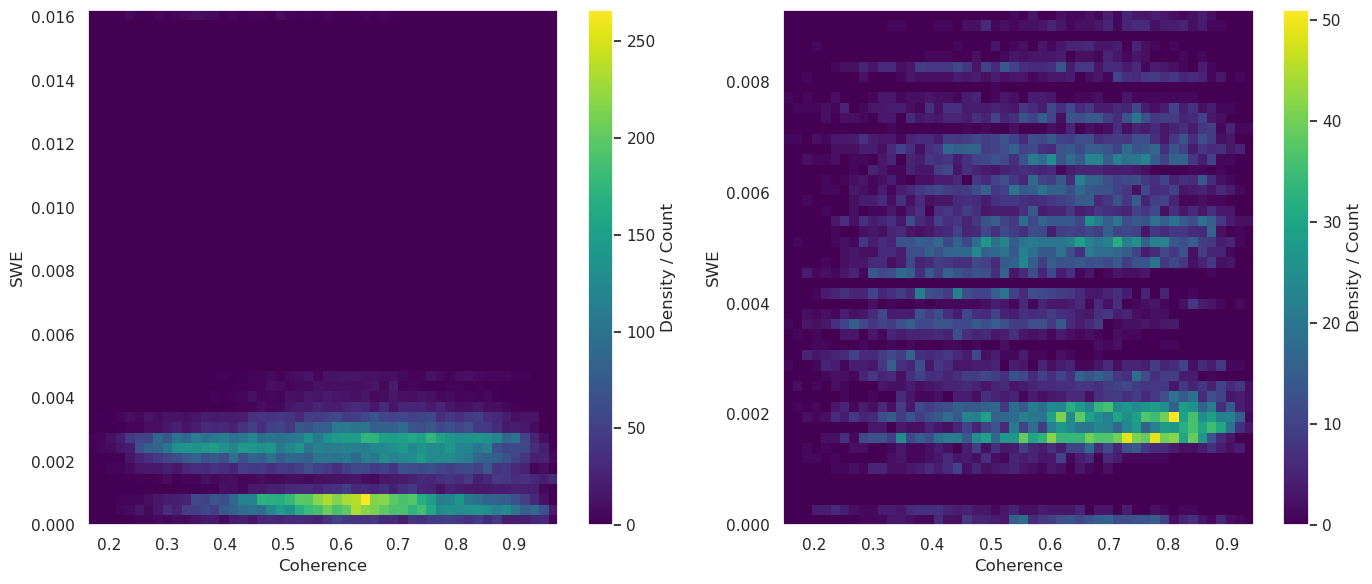

In [116]:
rmnp_clean = rmnp_df[['coherence', 'swe_accum']].dropna()

# 2. Clean slc_df similarly
slc_clean = slc_df[['coherence', 'swe_accum']].dropna()

# Quick sanity check: Ensure we actually have data left to plot
if rmnp_clean.empty or slc_clean.empty:
    raise ValueError("One of the DataFrames is completely empty after dropping NaNs! Check your data loading step.")

# 3. Plot using the cleaned data
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Heatmap for rmnp_df
h1 = axes[0].hist2d(
    rmnp_clean['coherence'], 
    rmnp_clean['swe_accum'], 
    bins=50, 
    cmap='viridis'
)
axes[0].set_ylabel('SWE')
axes[0].set_xlabel('Coherence')
fig.colorbar(h1[3], ax=axes[0], label='Density / Count')

# Heatmap for slc_df
h2 = axes[1].hist2d(
    slc_clean['coherence'], 
    slc_clean['swe_accum'], 
    bins=50, 
    cmap='viridis'
)
axes[1].set_ylabel('SWE')
axes[1].set_xlabel('Coherence')
fig.colorbar(h2[3], ax=axes[1], label='Density / Count')

plt.tight_layout()
plt.show()

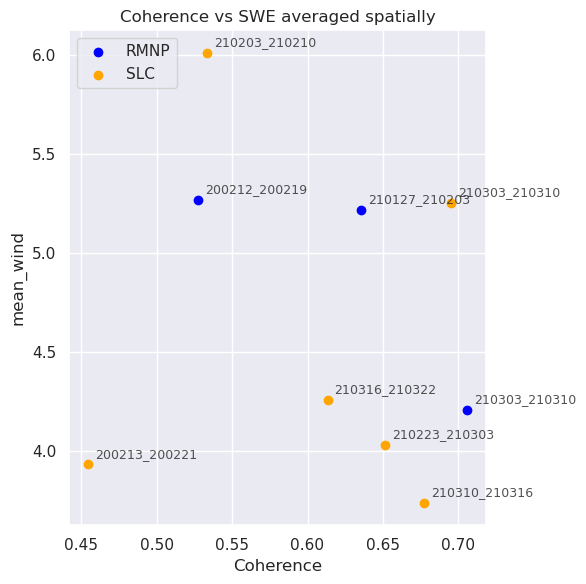

In [120]:
var_name = 'swe_accum'
var_name = 'mean_wind'

fig, axes = plt.subplots(1, 1, figsize=(6, 6))

rmnp_x = rmnp_filtered['coherence'].mean(dim=['x', 'y'])
rmnp_y = rmnp_filtered[var_name].mean(dim=['x', 'y'])

axes.scatter(rmnp_x.values, rmnp_y.values, color='blue', label='RMNP')
axes.set_ylabel(f'{var_name}')
axes.set_xlabel('Coherence')
axes.set_title('Coherence vs SWE averaged spatially')

# Loop through the pairs and annotate
for p in rmnp_filtered['pair'].values:
    x_val = rmnp_x.sel(pair=p).compute().item()
    y_val = rmnp_y.sel(pair=p).compute().item()
    
    axes.annotate(
        text=str(p),             # The text label (pair name)
        xy=(x_val, y_val),       # Point to label
        xytext=(5, 5),           # Offset text by 5 points north-east
        textcoords="offset points", 
        fontsize=9,
        alpha=0.8
    )

# --- Plot 2: SLC ---
# Calculate the means (keeps the 'pair' dimension)
slc_x = slc_filtered['coherence'].mean(dim=['x', 'y'])
slc_y = slc_filtered[var_name].mean(dim=['x', 'y'])

axes.scatter(slc_x.values, slc_y.values, color='orange', label='SLC')

# Loop through the pairs and annotate
for p in slc_filtered['pair'].values:
    x_val = slc_x.sel(pair=p).compute().item()
    y_val = slc_y.sel(pair=p).compute().item()
    
    axes.annotate(
        text=str(p), 
        xy=(x_val, y_val), 
        xytext=(5, 5), 
        textcoords="offset points", 
        fontsize=9,
        alpha=0.8
    )

axes.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [85]:
def map_swe_and_coherence(
    dataset, 
    var_name='swe_accum',
): 
    pair_names = dataset['pair'].values

    for i, p in enumerate(pair_names): 
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes = axes.flatten()

        to_plot = dataset.sel(pair=[p])

        to_plot['coherence'].plot(ax=axes[0], cmap='plasma', vmin=0, vmax=1, cbar_kwargs={'shrink': 0.7})
        to_plot[var_name].plot(ax=axes[1], cmap='Blues', cbar_kwargs={'shrink': 0.7})

        axes[0].set_title(f"Average Coherence: {to_plot['coherence'].mean().values:.5f}")
        axes[1].set_title(f"Average {var_name}: {to_plot[var_name].mean().values:.5f}")

        axes[0].set_aspect('equal')
        axes[1].set_aspect('equal')

        axes[0].tick_params(axis='x', labelrotation=45)
        axes[1].tick_params(axis='x', labelrotation=45)

        fig.suptitle(f'Pair: {p}')

        plt.tight_layout()
        plt.show()

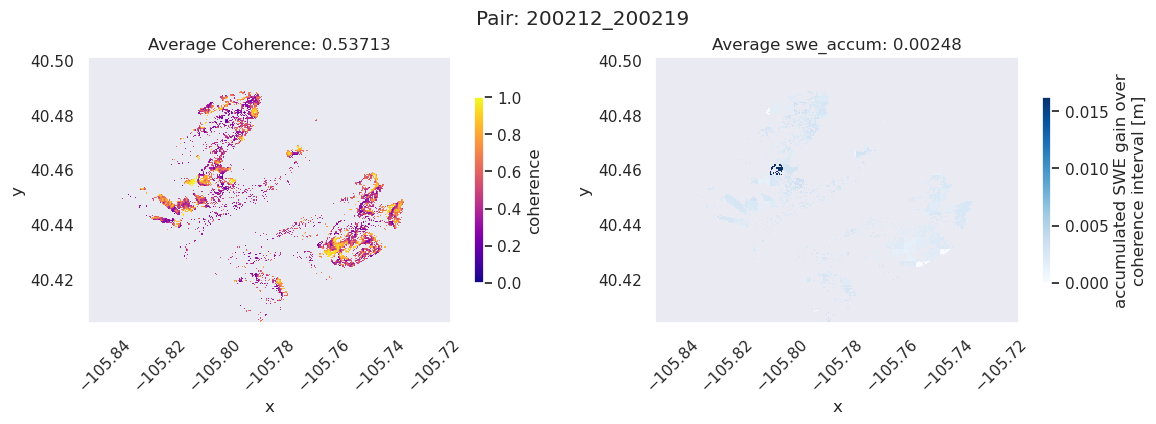

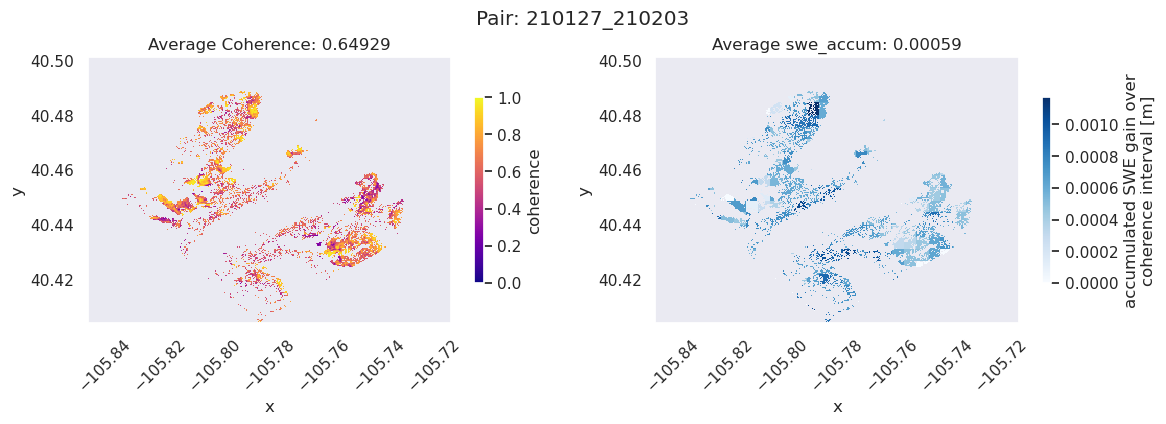

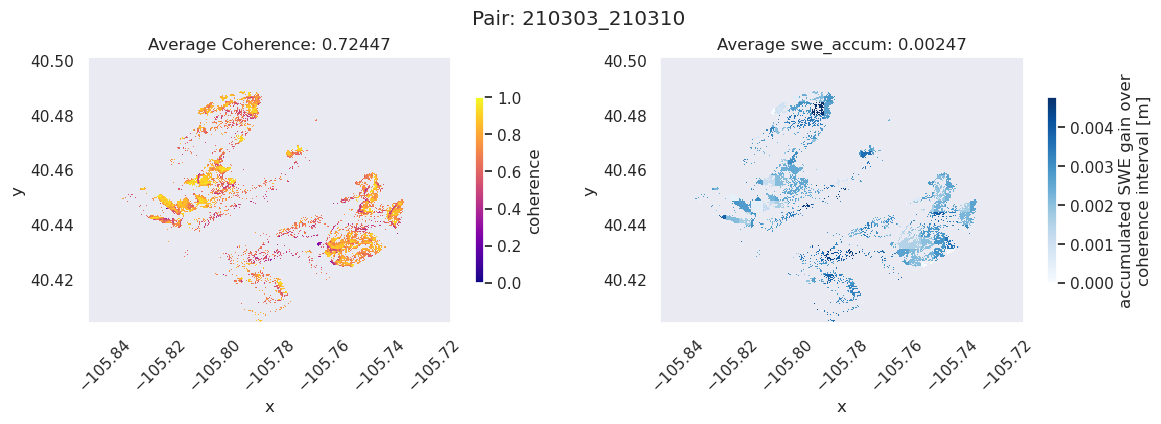

In [86]:
map_swe_and_coherence(rmnp_filtered, 
                      var_name='swe_accum')

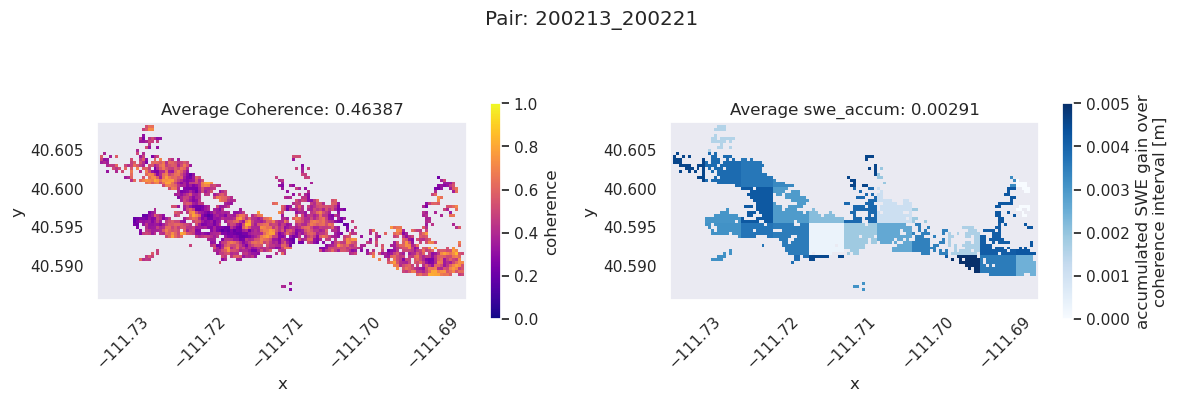

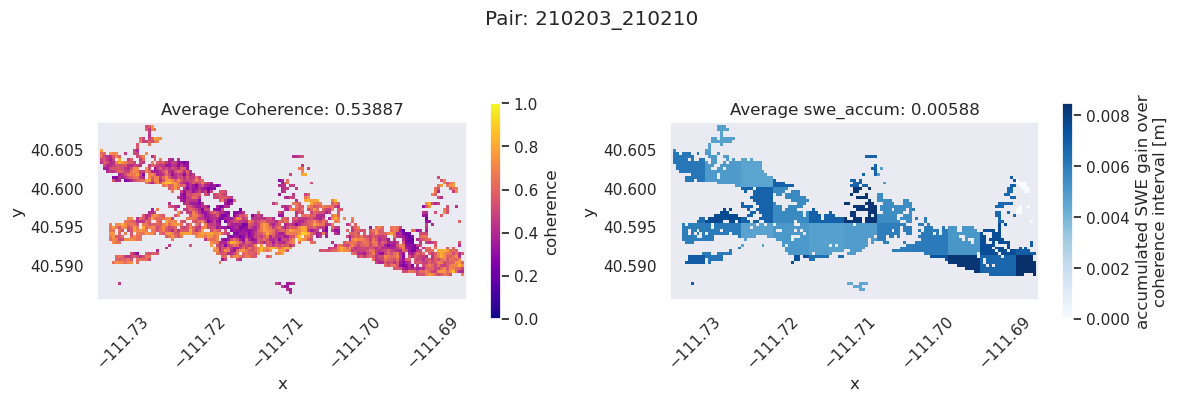

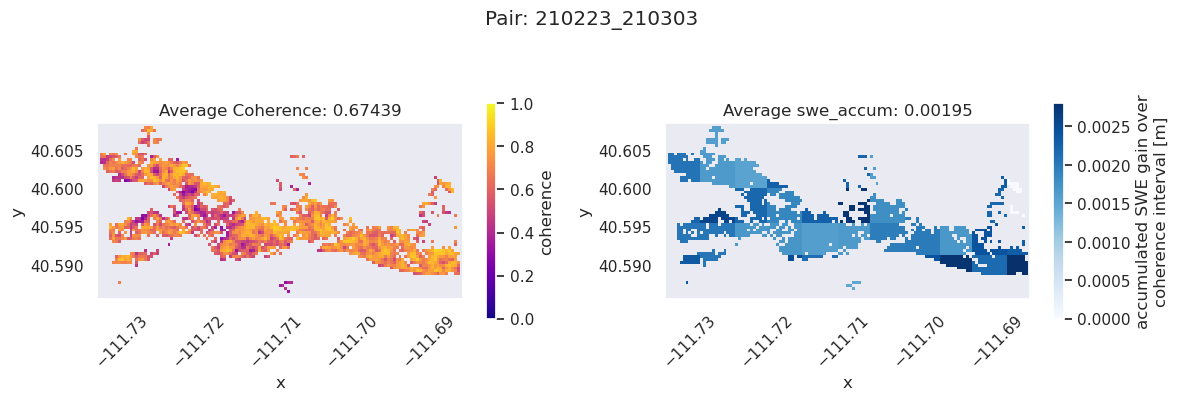

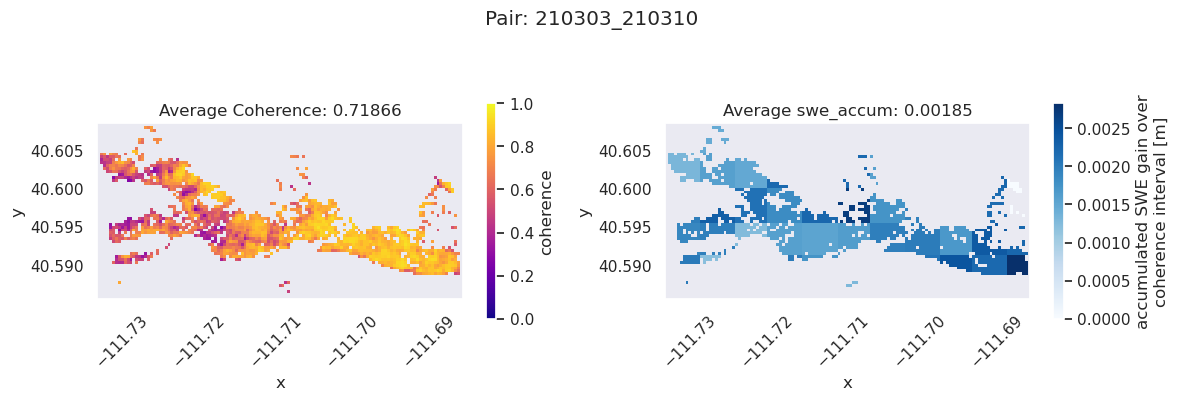

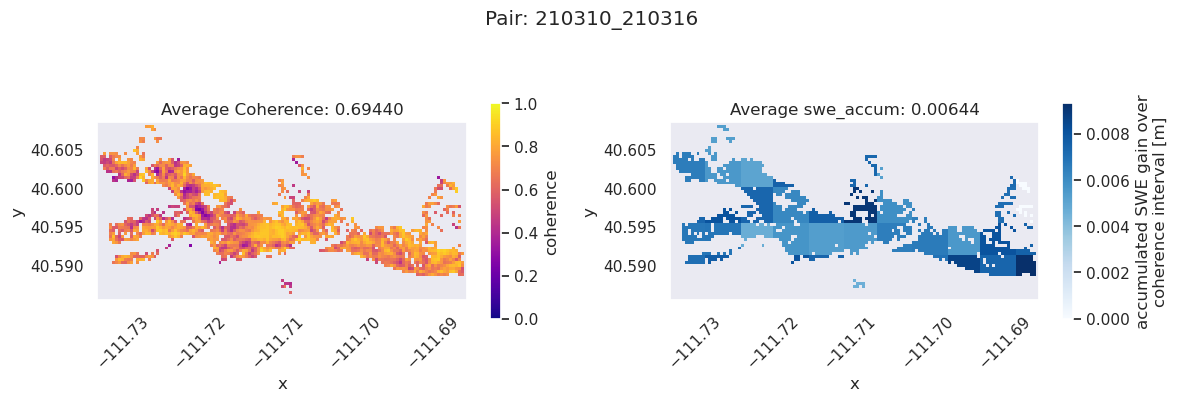

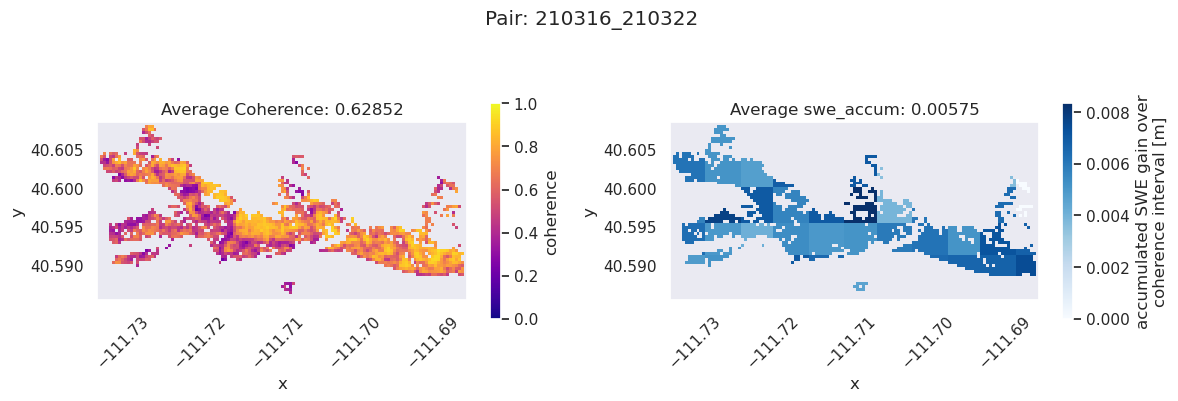

In [87]:
map_swe_and_coherence(slc_filtered, 
                      var_name='swe_accum')